In [1]:
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu128 -q
!pip install fair-esm -q # latest release, OR:
!pip install git+https://github.com/facebookresearch/esm.git  -q # bleeding edge, current repo main branch
!pip install biopython -q
!pip install torch_geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.8.0+cu128.html -q
!sudo apt-get update -qq
!sudo DEBIAN_FRONTEND=noninteractive apt-get install -y -qq dssp

import torch
from scipy.spatial import cKDTree
from Bio.PDB import PDBParser, Selection, PDBList, DSSP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.data import Data
import esm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 75.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 MB 1.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 75.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 100.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 6.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 19.4 MB/s eta 0:00:0000:0100:01
     

In [111]:
'''Hydrophobicity values for the 20 standard amino acids, according to Kyte & Doolittle (1982).'''

Hydrophobicity = {

'ALA':  1.800,  

'ARG': -4.500,  

'ASN': -3.500,  

'ASP': -3.500,  

'CYS':  2.500,  

'GLN': -3.500,  

'GLU': -3.500,  

'GLY': -0.400,  

'HIS': -3.200,  

'ILE':  4.500,  

'LEU':  3.800,  

'LYS': -3.900,

'MET':  1.900,  

'PHE':  2.800,  

'PRO': -1.600,  

'SER': -0.800,  

'THR': -0.700,  

'TRP': -0.900,  

'TYR': -1.300,  

'VAL':  4.200, }  


formal_charge = {
    "ARG":  1, "LYS":  1,
    "ASP": -1, "GLU": -1,
    "HIS":  0,  # neutral at pH 7 (protonated = +1, use PropKa for accuracy)
    "ALA":  0, "VAL":  0, "LEU":  0, "ILE":  0, "PRO":  0,
    "PHE":  0, "TRP":  0, "MET":  0, "GLY":  0, "SER":  0,
    "THR":  0, "CYS":  0, "TYR":  0, "ASN":  0, "GLN":  0,
}


Isoelectric_point = {
    "ALA":  6.11, "ARG": 10.76, "ASN":  5.43, "ASP":  2.98, "CYS":  5.15,
    "GLN":  5.65, "GLU":  3.08, "GLY":  6.06, "HIS":  7.64, "ILE":  6.04,
    "LEU":  6.04, "LYS":  9.47, "MET":  5.71, "PHE":  5.76, "PRO":  6.30,
    "SER":  5.70, "THR":  5.60, "TRP":  5.88, "TYR":  5.63, "VAL":  6.02,
}

# Side chain length — number of bonds from Cα to terminal heavy atom

Sidechain_length = {
    "GLY": 0, "ALA": 1, "SER": 2, "CYS": 2, "THR": 2, "VAL": 2,
    "ILE": 3, "LEU": 3, "ASP": 3, "ASN": 3, "PRO": 3,
    "GLU": 4, "GLN": 4, "MET": 4, "HIS": 4, "PHE": 4, "TYR": 4, "TRP": 4,
    "LYS": 5, "ARG": 6,
}

In [ ]:
import numpy as np
from scipy.spatial import cKDTree
from Bio.PDB import PDBParser, DSSP, Selection
from Bio.Data.PDBData import protein_letters_3to1 as three_to_one
import torch
from torch_geometric.data import Data
import esm
import hashlib
from pathlib import Path
from dataclasses import dataclass
from torch.utils.data import Dataset




HYDROPHOBICITY = Hydrophobicity
FORMAL_CHARGE = formal_charge
ISOELECTRIC_POINT = Isoelectric_point
SIDECHAIN_LENGTH = Sidechain_length

STANDARD_AA = set(HYDROPHOBICITY.keys())
DIELECTRIC_CONSTANT = 4.0   # distance-dependent dielectric (protein interior)

VDW_CUTOFF = 8.0
HBOND_ENERGY_THRESHOLD = -0.5
PEPTIDE_BOND_CUTOFF = 1.5  

STANDARD_AA = {
    "ALA", "ARG", "ASN", "ASP", "CYS", "GLN", "GLU", "GLY", "HIS", "ILE",
    "LEU", "LYS", "MET", "PHE", "PRO", "SER", "THR", "TRP", "TYR", "VAL"
}

# Edge type → integer label (for concatenation later)
EDGE_TYPE_MAP = {"peptide": 0, "vdw": 1, "hbond": 2}


class ProteinGraphBuilder:
    def __init__(self, pdb_path: str):
        self.pdb_path = pdb_path

        # --- Parse structure ---
        parser = PDBParser(QUIET=True)
        self.structure = parser.get_structure("protein", pdb_path)
        self.model = next(self.structure.get_models())

        self._raw_residues = [
            r for r in Selection.unfold_entities(self.model, "R")
            if "CA" in r
        ]

        # --- Sequence extraction + index mapping ---
        self.sequence, self.valid_indices, self.skipped = self._extract_sequence()

        # Final residue list — only standard AA residues, aligned to sequence
        self.residues = [self._raw_residues[i] for i in self.valid_indices]
        self.res_to_idx = {r: i for i, r in enumerate(self.residues)}

        # Precompute once — used by vdw_edges
        self._cb_coords_numpy = self._get_cb_coords()
        self._cb_coords = torch.Tensor(self._cb_coords_numpy)  # (N, 3)

        # Build DSSP → node index map once — used by hbond_edges
        self._dssp_to_node_idx = self._build_dssp_map()



        print(f"[ProteinGraphBuilder] {len(self.residues)} residues | "
              f"sequence length: {len(self.sequence)}")
        if self.skipped:
            print(f"  Skipped: {[(i, r.get_resname(), reason) for i, r, reason in self.skipped]}")

    # ------------------------------------------------------------------
    # Sequence extraction
    # ------------------------------------------------------------------

    def _extract_sequence(self) -> tuple[str, list[int], list]:
        sequence, valid_indices, skipped = [], [], []

        for i, res in enumerate(self._raw_residues):
            resname = res.get_resname().strip()
            het, resseq, icode = res.get_id()

            if het.strip():
                skipped.append((i, res, "HETATM"))
                continue
            if resname not in STANDARD_AA:
                skipped.append((i, res, f"non-standard: {resname}"))
                continue
            try:
                one_letter = three_to_one[resname]
            except KeyError:
                skipped.append((i, res, "no one-letter code"))
                continue
            if icode.strip():
                print(f"  [insertion] resseq={resseq} icode={icode} ({resname}) at index {i}")

            sequence.append(one_letter)
            valid_indices.append(i)

        return "".join(sequence), valid_indices, skipped

    # ------------------------------------------------------------------
    # Coordinate helpers
    # ------------------------------------------------------------------

    def _get_cb_coords(self) -> np.ndarray:
        """
        Cβ for all standard residues, Cα fallback for Glycine.
        Precomputed once at init — do not call this repeatedly.
        """
        coords = []
        for res in self.residues:
            atom = res["CB"] if "CB" in res else res["CA"]
            coords.append(atom.get_vector().get_array())
        return np.array(coords)  # (N, 3)

    # ------------------------------------------------------------------
    # DSSP → node index mapping
    # ------------------------------------------------------------------

    def _build_dssp_map(self) -> dict:
        """
        Maps each DSSP key (chain_id, res_id) → node index in self.residues.
        DSSP may drop terminal residues or residues it can't assign, so this
        mapping will be partial — missing entries are silently skipped in hbond_edges.
        """
        dssp_map = {}
        for res in self.residues:
            chain_id = res.get_parent().id
            res_id = res.get_id()          # (het, resseq, icode)
            dssp_key = (chain_id, res_id)
            node_idx = self.res_to_idx[res]
            dssp_map[dssp_key] = node_idx
        return dssp_map

    # ------------------------------------------------------------------
    # Edge builders
    # ------------------------------------------------------------------

    def peptide_edges(self) -> list[tuple]:
        """
        Consecutive residues in the same chain connected by a real C→N bond.
        Checks atomic distance to exclude chain breaks (missing residues in PDB).
        Weight is fixed at 1.0 — covalent bonds are binary.
        """
        edges = []
        for i in range(len(self.residues) - 1):
            r1, r2 = self.residues[i], self.residues[i + 1]

            # Must be same chain
            if r1.get_parent().id != r2.get_parent().id:
                continue

            # Check actual C(i) → N(i+1) bond distance to detect chain breaks
            if "C" not in r1 or "N" not in r2:
                continue
            c_coord = r1["C"].get_vector().get_array()
            n_coord = r2["N"].get_vector().get_array()
            bond_dist = float(np.linalg.norm(c_coord - n_coord))

            if bond_dist <= PEPTIDE_BOND_CUTOFF:
                edges.append((i, i + 1, 1.0, "peptide"))

        return edges

    def vdw_edges(self) -> list[tuple]:
        """
        Residue pairs within VDW_CUTOFF Å (Cβ–Cβ distance).
        Weight is a Gaussian decay — closer residues get higher weight.
        query_pairs() already excludes self-loops and duplicate pairs.
        """
        tree = cKDTree(self._cb_coords_numpy)
        edges = []
        for i, j in tree.query_pairs(r=VDW_CUTOFF):
            dist = float(np.linalg.norm(self._cb_coords[i] - self._cb_coords[j]))
            weight = float(np.exp(-dist / VDW_CUTOFF))
            edges.append((i, j, weight, "vdw"))
        return edges

    def hbond_edges(self) -> list[tuple]:
        dssp = DSSP(self.model, self.pdb_path, dssp="mkdssp", file_type="PDB")
        edges = []
 
        # Bug fix: outside the loop — was recomputed on every iteration before
        dssp_keys_list = list(dssp.keys())
 
        for idx, key in enumerate(dssp_keys_list):
            data = dssp[key]
            for offset_field, energy_field in [(6, 7), (8, 9)]:
                offset = data[offset_field]
                energy = data[energy_field]
 
                if energy >= HBOND_ENERGY_THRESHOLD or offset == 0:
                    continue
 
                partner_dssp_idx = idx + offset
                if not (0 <= partner_dssp_idx < len(dssp_keys_list)):
                    continue
 
                partner_key = dssp_keys_list[partner_dssp_idx]
                src_node = self._dssp_to_node_idx.get(key)
                dst_node = self._dssp_to_node_idx.get(partner_key)
 
                if src_node is None or dst_node is None:
                    continue
 
                edges.append((src_node, dst_node, float(abs(energy)), "hbond"))
 
        return edges
    
    def get_coulomb_term(self, src: torch.Tensor, dst: torch.Tensor) -> torch.Tensor:
        """
        Screened Coulomb interaction for each edge: q_i * q_j / (ε * r_ij)
    
        Uses a distance-dependent dielectric (ε = DIELECTRIC_CONSTANT * r_ij)
        which is standard for protein interiors to account for screening.
        Final formula: q_i * q_j / (ε * r_ij²)
    
        Returns (E,) float tensor — one value per directed edge.
        Positive = repulsive (same charge), Negative = attractive (opposite charge).
        Zero if either residue is uncharged.
        """
        charges = torch.tensor(
            [float(FORMAL_CHARGE.get(r.get_resname().strip(), 0)) for r in self.residues],
            dtype=torch.float
        )
    
        q_src = charges[src]   # (E,)
        q_dst = charges[dst]   # (E,)
    
        src_np = self._cb_coords_numpy[src.numpy()]
        dst_np = self._cb_coords_numpy[dst.numpy()]
        r = torch.tensor(np.linalg.norm(src_np - dst_np, axis=1),dtype=torch.float).clamp(min=1e-6)  # avoid division by zero
    
        # Distance-dependent dielectric: ε(r) = ε₀ * r
        coulomb = q_src * q_dst / (DIELECTRIC_CONSTANT * r ** 2)
        return coulomb  # (E,)
    

    ### ----------------------------------------------------------------
    # Node feature builders
    # ----------------------------------------------------------------

    def get_one_hot(self) -> torch.Tensor:
        """
        One-hot encoding of amino acid identity. Returns (N, 20) float tensor.
        Order is alphabetical by 3-letter code.
        """
        aa_list = sorted(STANDARD_AA)
        aa_to_idx = {aa: i for i, aa in enumerate(aa_list)}
    
        one_hot = torch.zeros(len(self.residues), len(aa_list))
        for i, res in enumerate(self.residues):
            resname = res.get_resname().strip()
            if resname in aa_to_idx:
                one_hot[i, aa_to_idx[resname]] = 1.0
        return one_hot
    

    def get_hydrophobicity(self) -> torch.Tensor:
        """
        Kyte-Doolittle scale. Returns (N,) float tensor.
        Range: -4.5 (hydrophilic) to +4.5 (hydrophobic).
        """

        return torch.tensor(
            [[HYDROPHOBICITY.get(r.get_resname().strip(), 0.0)] for r in self.residues],
            dtype=torch.float)
    
    def get_formal_charge(self) -> torch.Tensor:
        """
        Integer formal charge at pH 7. Returns (N,) float tensor.
        Values: -1, 0, or +1.
        """
        return torch.tensor(
            [[float(FORMAL_CHARGE.get(r.get_resname().strip(), 0))] for r in self.residues],
            dtype=torch.float
        )

        
        
    def get_isoelectric_point(self) -> torch.Tensor:
        """
        Approximate pI per residue. Returns (N,) float tensor.
        """
        return torch.tensor(
            [[ISOELECTRIC_POINT.get(r.get_resname().strip(), 5.97)] for r in self.residues],
            dtype=torch.float
        )
    
    def get_sidechain_length(self, use_coords: bool = True) -> torch.Tensor:
        """
        Side chain length per residue.
    
        Args:
            use_coords: If True, computes Euclidean distance between Cα and
                        the farthest sidechain heavy atom from PDB coordinates.
                        More physically accurate but requires complete sidechain.
                        Falls back to lookup table if sidechain atoms are missing.
                        If False, uses the bond-count lookup table directly.
    
        Returns: (N,) float tensor
        """
        lengths = []
        for res in self.residues:
            resname = res.get_resname().strip()
    
            if use_coords and "CA" in res:
                ca = res["CA"].get_vector().get_array()
                sidechain_atoms = [
                    atom for atom in res.get_atoms()
                    if atom.get_name() not in ("N", "CA", "C", "O")  # exclude backbone
                ]
                if sidechain_atoms:
                    distances = [
                        np.linalg.norm(atom.get_vector().get_array() - ca)
                        for atom in sidechain_atoms
                    ]
                    lengths.append([float(max(distances))])
                    continue
    
            # Fallback to bond count lookup
            lengths.append([float(SIDECHAIN_LENGTH.get(resname, 0))])
    
        return torch.tensor(lengths, dtype=torch.float)

    # ------------------------------------------------------------------
    # Graph builder
    # ------------------------------------------------------------------

    def build(self, node_features: torch.Tensor | None = None,
            contacts: torch.Tensor | None = None, y: torch.Tensor | None = None) -> Data:

        all_edges = self.peptide_edges() + self.vdw_edges() + self.hbond_edges()

        src = torch.tensor([e[0] for e in all_edges], dtype=torch.long)
        dst = torch.tensor([e[1] for e in all_edges], dtype=torch.long)

        edge_index = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])])

        weights = torch.tensor([e[2] for e in all_edges], dtype=torch.float)
        types   = torch.tensor([EDGE_TYPE_MAP[e[3]] for e in all_edges], dtype=torch.float)

        zero        = torch.zeros_like(weights)
        contacts_fw = contacts[src, dst] if contacts is not None else zero
        contacts_rv = contacts[dst, src] if contacts is not None else zero

        coulomb_fw = self.get_coulomb_term(src, dst)
        coulomb_rv = self.get_coulomb_term(dst, src)

        scalar_fw = torch.stack([weights, types, contacts_fw, coulomb_fw], dim=1)  # (E, 4)
        scalar_rv = torch.stack([weights, types, contacts_rv, coulomb_rv], dim=1)  # (E, 4)
        edge_attr = torch.cat([scalar_fw, scalar_rv], dim=0)                       # (2E, 4)

        # None check before concat — zeros must match ESM2 dim so cat stays (N, 1304)
        if node_features is None:
            print("[ProteinGraphBuilder] No node features — using zeros.")
            node_features = torch.zeros((len(self.residues), 1280), dtype=torch.float)  # ← 1280 not 1

        assert node_features.shape[0] == len(self.residues), (
            f"node_features {node_features.shape[0]} != residues {len(self.residues)}"
        )

        node_features = torch.cat([
            node_features,                               # (N, 1280)
            self.get_one_hot(),                          # (N, 20)
            self.get_hydrophobicity(),                   # (N, 1)
            self.get_formal_charge(),                    # (N, 1)
            self.get_isoelectric_point(),                # (N, 1)
            self.get_sidechain_length(use_coords=True),  # (N, 1)
        ], dim=1)  # (N, 1304)

        return Data(
            x=node_features,
            pos=self._cb_coords,        # torch.Tensor (N, 3)
            edge_index=edge_index,
            edge_attr=edge_attr,
            num_nodes=len(self.residues),
            y=y

        )
        

@dataclass
class ESMOutput:
    embeddings: torch.Tensor   # (L, 1280) — per-residue, last layer
    contacts:   torch.Tensor   # (L, L)    — predicted from attention heads
    sequence:   str


class ESMProcessor:
    def __init__(
        self,
        cache_dir: str = ".esm_cache",
        device: str = "cuda",
        repr_layer: int = 33,          # last layer of esm2_t33_650M_UR50D
        batch_token_limit: int = 1024,
    ):
        self.device = device
        self.repr_layer = repr_layer
        self.batch_token_limit = batch_token_limit
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self._model = None
        self._alphabet = None
        self._batch_converter = None

    # ------------------------------------------------------------------
    # Lazy load
    # ------------------------------------------------------------------

    def _load_model(self):
        if self._model is None:
            print("[ESMProcessor] Loading ESM2...")
            self._model, self._alphabet = esm.pretrained.esm2_t33_650M_UR50D()
            self._batch_converter = self._alphabet.get_batch_converter()
            self._model = self._model.eval().to(self.device)
            print("[ESMProcessor] Ready.")

    # ------------------------------------------------------------------
    # Cache
    # ------------------------------------------------------------------

    def _cache_path(self, sequence: str) -> Path:
        key = hashlib.md5(sequence.encode()).hexdigest()
        return self.cache_dir / f"{key}.pt"

    def _load_cache(self, sequence: str) -> ESMOutput | None:
        path = self._cache_path(sequence)
        if path.exists():
            data = torch.load(path, map_location="cpu")
            return ESMOutput(**data)
        return None

    def _save_cache(self, sequence: str, output: ESMOutput):
        torch.save({
            "embeddings": output.embeddings,
            "contacts":   output.contacts,
            "sequence":   output.sequence,
        }, self._cache_path(sequence))

    # ------------------------------------------------------------------
    # Core inference — takes (label, seq) tuples, returns raw results
    # ------------------------------------------------------------------

    def _run_inference(self, labeled_seqs: list[tuple[str, str]]) -> dict:
        """
        labeled_seqs: list of ("label", "SEQUENCE") tuples
        Returns raw ESM2 results dict.
        """
        _, _, batch_tokens = self._batch_converter(labeled_seqs)
        batch_tokens = batch_tokens.to(self.device)

        with torch.no_grad():
            results = self._model(
                batch_tokens,
                repr_layers=[self.repr_layer],
                return_contacts=True,
            )
        return results, batch_tokens

    # ------------------------------------------------------------------
    # Single sequence
    # ------------------------------------------------------------------

    def process(self, sequence: str) -> ESMOutput:
        cached = self._load_cache(sequence)
        if cached is not None:
            return cached

        self._load_model()

        results, _ = self._run_inference([("protein", sequence)])

        L = len(sequence)
        output = ESMOutput(
            # Slice [1 : L+1] to remove BOS token (index 0) and EOS token (index L+1)
            embeddings=results["representations"][self.repr_layer][0, 1:L+1].cpu(),  # (L, 1280)
            contacts=results["contacts"][0, :L, :L].cpu(),                           # (L, L)
            sequence=sequence,
        )
        self._save_cache(sequence, output)
        return output

    # ------------------------------------------------------------------
    # Batch — length sorted to minimize padding waste
    # ------------------------------------------------------------------

    def process_batch(self, sequences: list[str]) -> list[ESMOutput]:
        results = {}

        # Cache hits
        uncached = []
        for i, seq in enumerate(sequences):
            cached = self._load_cache(seq)
            if cached is not None:
                results[i] = cached
            else:
                uncached.append((i, seq))

        if not uncached:
            return [results[i] for i in range(len(sequences))]

        self._load_model()

        # Sort by length — minimizes padding waste per bucket
        uncached.sort(key=lambda x: len(x[1]))

        # Build length-aware buckets within token limit
        batches = []
        current_batch = []
        current_max_len = 0

        for i, seq in uncached:
            new_max = max(current_max_len, len(seq))
            projected_tokens = new_max * (len(current_batch) + 1)

            if current_batch and projected_tokens > self.batch_token_limit:
                batches.append(current_batch)
                current_batch = [(i, seq)]
                current_max_len = len(seq)
            else:
                current_batch.append((i, seq))
                current_max_len = new_max

        if current_batch:
            batches.append(current_batch)

        # Run inference per bucket
        for batch in batches:
            indices, seqs = zip(*batch)
            labeled = [(str(idx), seq) for idx, seq in zip(indices, seqs)]

            raw, _ = self._run_inference(labeled)

            for k, (orig_idx, seq) in enumerate(zip(indices, seqs)):
                L = len(seq)
                output = ESMOutput(
                    embeddings=raw["representations"][self.repr_layer][k, 1:L+1].cpu(),
                    contacts=raw["contacts"][k, :L, :L].cpu(),
                    sequence=seq,
                )
                self._save_cache(seq, output)
                results[orig_idx] = output

        return [results[i] for i in range(len(sequences))]
    

def parse_binding_residues(binding_str: str) -> list[tuple[str, int]]:
    """
    Parses 'F43 R45 V68 S92' → [('F', 43), ('R', 45), ('V', 68), ('S', 92)]
    Returns list of (one_letter_AA, resseq) tuples.
    """
    result = []
    for token in binding_str.split():
        aa      = token[0]          # one-letter AA — use for validation
        resseq  = int(token[1:])    # PDB residue number
        result.append((aa, resseq))
    return result


def get_binding_indices(
    builder: "ProteinGraphBuilder",
    binding_residues: list[tuple[str, int]],
    validate_aa: bool = True,
) -> list[int]:
    """
    Maps (AA, resseq) tuples → node indices in builder.residues.
    Skips residues not found in the structure (chain breaks, filtered out, etc).

    Args:
        validate_aa: If True, warns when the AA letter doesn't match the
                     residue at that resseq — catches PDB numbering mismatches.
    """
    from Bio.Data.PDBData import protein_letters_3to1 as three_to_one

    # Build resseq → (node_idx, one_letter) lookup
    resseq_map = {}
    for i, res in enumerate(builder.residues):
        resseq  = res.get_id()[1]                          # integer PDB resseq
        resname = res.get_resname().strip()
        one_letter = three_to_one.get(resname, "?")
        resseq_map[resseq] = (i, one_letter)

    binding_indices = []
    for aa, resseq in binding_residues:
        if resseq not in resseq_map:
            print(f"  [warning] resseq {resseq} ({aa}) not found in structure — skipped")
            continue

        node_idx, actual_aa = resseq_map[resseq]

        if validate_aa and aa != actual_aa:
            print(f"  [warning] resseq {resseq}: expected {aa}, found {actual_aa} — included anyway")

        binding_indices.append(node_idx)

    return binding_indices
    


class ProteinDataset(Dataset):
    def __init__(self, pdb_paths: list[str], binding_residues: list[str], esm_processor: ESMProcessor):
        self.pdb_paths = pdb_paths
        self.processor = esm_processor

        # Build all graph builders first (fast, CPU only)
        print("Parsing PDB files...")
        self.builders = [ProteinGraphBuilder(p) for p in pdb_paths]

        print("Processing binding residues...")

        self.binding_residues = [parse_binding_residues(br) for br in binding_residues]
        self.binding_residue_indices = [
            get_binding_indices(builder, br, validate_aa=True)
            for builder, br in zip(self.builders, self.binding_residues)
        ]

        # Batch all sequences through ESMFold in one pass
        print("Running ESMFold...")
        sequences = [b.sequence for b in self.builders]
        self.esm_outputs = self.processor.process_batch(sequences)


    def __len__(self):
        return len(self.builders)

    def __getitem__(self, idx) -> Data:
        builder = self.builders[idx]
        esm_out = self.esm_outputs[idx]
        bind_idx   = self.binding_residue_indices[idx]

        y = torch.zeros(len(builder.residues), dtype=torch.float)
        y[bind_idx] = 1.0


        # ESMFold also gives you a contact map — you can add it as edge weights
        # or use it to add/filter edges here before building
        node_features = esm_out.embeddings   # (L, 1024) — projection happens in GNN
        edge_attention = esm_out.contacts
        return builder.build(node_features=node_features, contacts = edge_attention, y=y)


In [222]:
from Bio.PDB import PDBList, PDBIO, Select, PDBParser
from pathlib import Path


class ChainSelect(Select):
    def __init__(self, chain_id: str):
        self.chain_id = chain_id

    def accept_chain(self, chain):
        return chain.id == self.chain_id


def download_and_split_chains(
    annotation_file: str,
    raw_dir: str,       # full PDBs downloaded here — temporary
    receptor_dir: str,  # chain-split PDBs saved here — used by dataset
) -> tuple[list[str], list[str]]:
    """
    Reads BioLiP annotation file, downloads full PDBs, extracts the
    relevant chain, saves to receptor_dir, and discards the full PDB.

    Returns parallel lists of (pdb_paths, binding_residue_strings)
    ready to pass directly into ProteinDataset.
    """
    Path(raw_dir).mkdir(parents=True, exist_ok=True)
    Path(receptor_dir).mkdir(parents=True, exist_ok=True)

    pdbl = PDBList()
    parser = PDBParser(QUIET=True)
    io = PDBIO()

    pdb_paths        = []
    binding_residues = []
    failed           = []

    with open(annotation_file) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            cols    = line.split("\t")
            pdb_id  = cols[0]   # e.g. 966c
            chain   = cols[1]   # e.g. A
            binding = cols[7]   # e.g. N180 L181 A182 ...

            if not binding.strip() or binding == "-":
                print(f"[skip] {pdb_id}{chain} — no binding residues annotated")
                continue

            out_path = Path(receptor_dir) / f"{pdb_id}{chain}.pdb"

            # Skip download if already processed
            if out_path.exists():
                pdb_paths.append(str(out_path))
                binding_residues.append(binding.strip())
                continue

            try:
                # Download full PDB into raw_dir
                full_path = pdbl.retrieve_pdb_file(
                    pdb_id,
                    pdir=raw_dir,
                    file_type="pdb"
                )

                # Parse and extract chain
                structure = parser.get_structure(pdb_id, full_path)

                io.set_structure(structure)
                io.save(str(out_path), ChainSelect(chain))

                # Discard full PDB
                Path(full_path).unlink()

                print(f"[ok] {pdb_id}{chain}.pdb saved")
                pdb_paths.append(str(out_path))
                binding_residues.append(binding.strip())

            except Exception as e:
                print(f"[error] {pdb_id}{chain}: {e}")
                failed.append(f"{pdb_id}{chain}")

    print(f"\nDone — {len(pdb_paths)} structures ready | {len(failed)} failed")
    if failed:
        print(f"Failed: {failed}")

    return pdb_paths, binding_residues

In [ ]:
from Bio.PDB import PDBList, PDBIO, Select

class ChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id

    def accept_chain(self, chain):
        return chain.id == self.chain_id


def download_and_extract_chain(pdb_id: str, chain: str, save_dir: str) -> str:
    """
    Downloads full PDB via PDBList then extracts the specified chain.
    """
    save_dir = Path(save_dir)
    out_path = save_dir / f"{pdb_id}{chain}.pdb"

    if out_path.exists():
        return str(out_path)

    # Download full structure
    pdbl = PDBList()
    full_path = pdbl.retrieve_pdb_file(pdb_id, pdir=str(save_dir), file_type="pdb")

    # Extract chain
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, full_path)

    io = PDBIO()
    io.set_structure(structure)
    io.save(str(out_path), ChainSelect(chain))

    # Remove the full PDB — no longer needed
    Path(full_path).unlink()
    print(f"Extracted chain {chain} from {pdb_id} → {out_path.name}")

    return str(out_path)


def parse_biolip(annotation_file: str, receptor_dir: str) -> tuple[list[str], list[str]]:
    pdb_paths, binding_residues = [], []

    with open(annotation_file) as f:
        for line in f:
            cols = line.strip().split("\t")
            pdb_id, chain, binding = cols[0], cols[1], cols[7]

            if binding == "-" or not binding.strip():
                continue

            # Option 1 — BioLiP direct (recommended)
            path = download_and_extract_chain(pdb_id, chain, receptor_dir)

            # Option 2 — PDBList + chain extraction
            # path = download_and_extract_chain(pdb_id, chain, receptor_dir)

            if path is None:
                continue

            pdb_paths.append(path)
            binding_residues.append(binding.strip())

    return pdb_paths, binding_residues

In [218]:
PDBList().download_pdb_files(['101MA'], pdir='.', file_format='pdb')

Desired structure not found or download failed. '101ma': HTTP Error 404: Not Found


In [203]:
# Usage
processor = ESMProcessor(cache_dir=".esm_cache", device="cuda")

dataset = ProteinDataset(
    pdb_paths=["/content/pdb101m.pdb"], binding_residues= ['F43 R45 V68 S92 H93 H97 I99 Y103'],
    esm_processor=processor   # one model instance, reused for all
)

Parsing PDB files...
[ProteinGraphBuilder] 154 residues | sequence length: 154
Processing binding residues...
Running ESMFold...


In [204]:
x_1 = dataset.__getitem__(0)

In [205]:
x_1

Data(x=[154, 1304], edge_index=[2, 2254], edge_attr=[2254, 4], y=[154], pos=[154, 3], num_nodes=154)

In [223]:
def edge_to_dense(data, num_nodes=None, edge_attr_channel=0):
    edge_index = data.edge_index
    edge_attr = data.edge_attr

    if num_nodes is None:
        num_nodes = data.num_nodes

    # Initialize adjacency matrix
    A = torch.zeros((num_nodes, num_nodes), dtype=torch.float32)

    # If edge_attr is multi-dimensional, pick a channel or reduce
    if edge_attr is not None:
        if edge_attr.dim() > 1:
            edge_attr = edge_attr[:, edge_attr_channel]
    else:
        edge_attr = torch.ones(edge_index.size(1))  # fallback

    # Fill matrix
    for i in range(edge_index.size(1)):
        if edge_attr[i] == 0:
            continue  # skip zero-weight edges
        src = edge_index[0, i]
        dst = edge_index[1, i]
        A[src, dst] = edge_attr[i]

    return A / (A.max() + 1e-8)

weights = edge_to_dense(x_1, edge_attr_channel=0) 
types = edge_to_dense(x_1, edge_attr_channel=1)
attention = edge_to_dense(x_1, edge_attr_channel=2)
coulomb = edge_to_dense(x_1, edge_attr_channel=3)

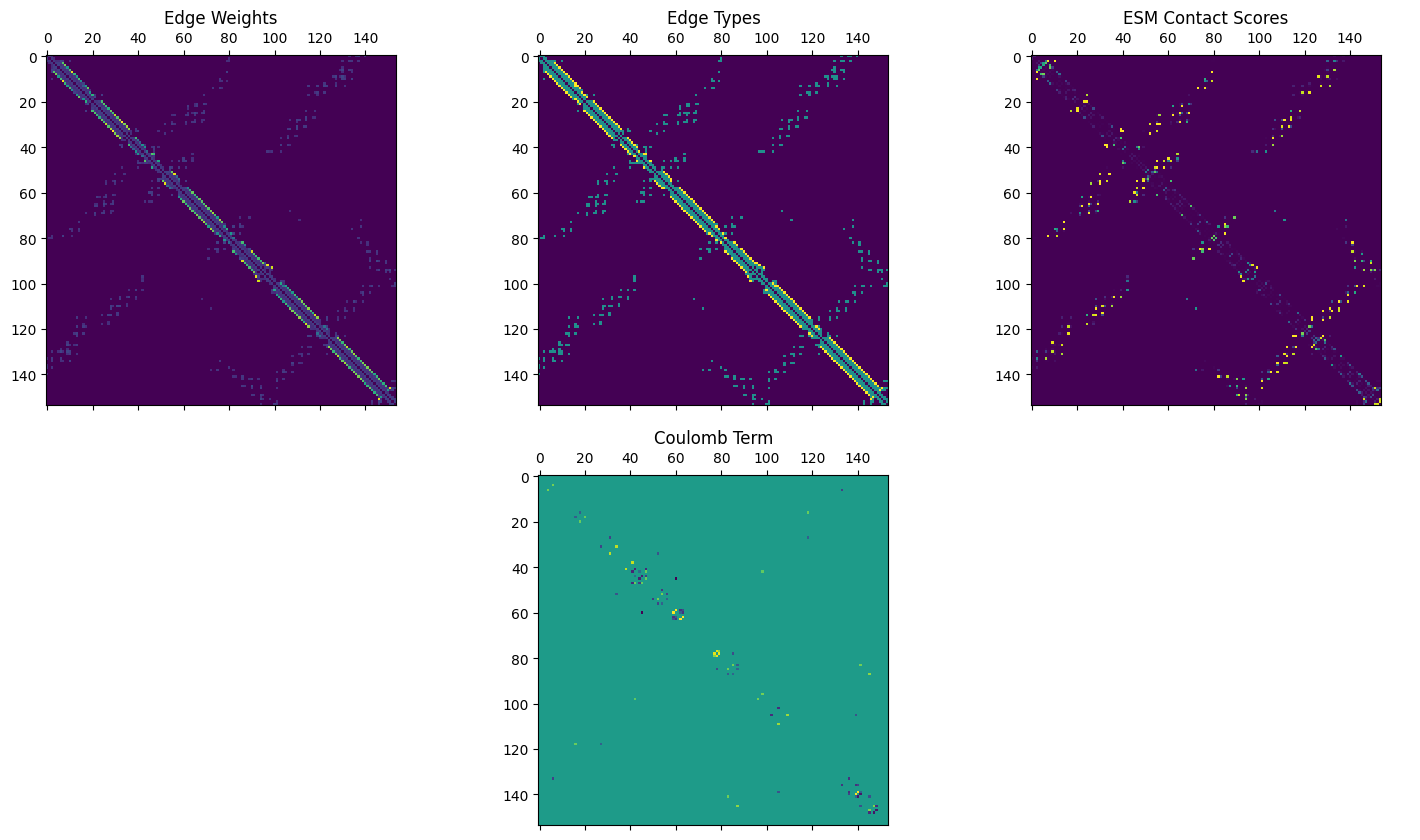

In [224]:

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].matshow(weights, cmap="viridis")
ax[0, 0].set_title("Edge Weights")

ax[0, 1].matshow(types.numpy(), cmap="viridis")
ax[0, 1].set_title("Edge Types")

ax[0, 2].matshow(attention.numpy(), cmap="viridis")
ax[0, 2].set_title("ESM Contact Scores")

ax[1, 0].axis("off")  # Hide unused subplot

combined = weights * attention   # Element-wise product to combine weight and contact score

ax[1, 1].matshow(coulomb, cmap="viridis")
ax[1, 1].set_title("Coulomb Term")

ax[1, 2].axis("off")  # Hide unused subplot


plt.show()



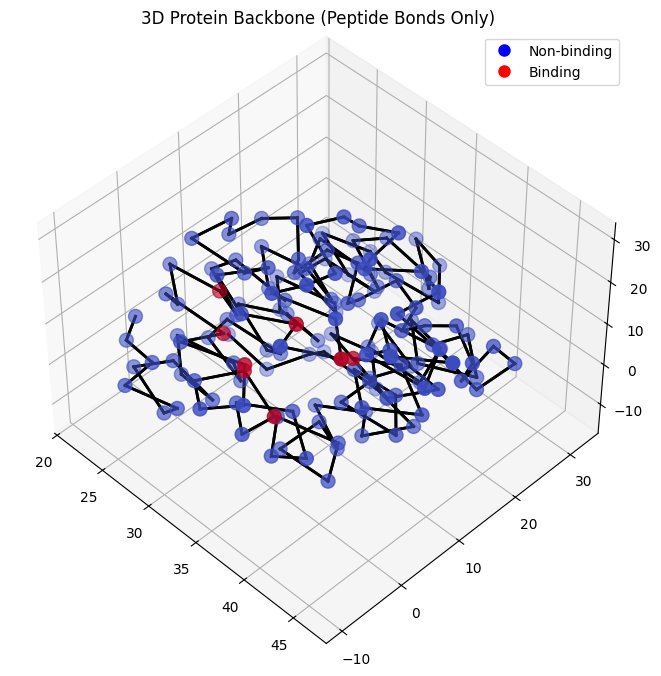

In [231]:
import matplotlib.pyplot as plt

def backbone_graph(data):

    node_xyz = data.pos  # (N, 3)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=45., azim=-45)

    binding_dictionary = {0: 'Non-binding', 1: 'Binding'}

    # Nodes
    ax.scatter(
        node_xyz[:, 0],
        node_xyz[:, 1],
        node_xyz[:, 2],
        c= x_1.y.numpy(),  # color by binding label
        cmap='coolwarm',
        s=100
    )

    plt.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', label='Non-binding', markerfacecolor='blue', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Binding', markerfacecolor='red', markersize=10)
    ])

    # Filter peptide bonds (edge_type == 0)
    peptide_mask = x_1.edge_attr[:, 1] == 0
    peptide_edges = x_1.edge_index[:, peptide_mask]

    for i in range(peptide_edges.size(1)):
        u, v = peptide_edges[0, i].item(), peptide_edges[1, i].item()
        x = [node_xyz[u, 0], node_xyz[v, 0]]
        y = [node_xyz[u, 1], node_xyz[v, 1]]
        z = [node_xyz[u, 2], node_xyz[v, 2]]
        ax.plot(x, y, z, color="black", linewidth=2)



    ax.set_title("3D Protein Backbone (Peptide Bonds Only)")
    plt.show()

In [212]:
x_1

Data(x=[154, 1304], edge_index=[2, 2254], edge_attr=[2254, 4], y=[154], pos=[154, 3], num_nodes=154)

In [164]:
x_1.edge_attr.size()

torch.Size([2254, 3])

In [216]:
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
from torch_geometric.utils import to_networkx



def visualize_graph(G, color):
    plt.figure(figsize=(15,9))
    plt.xticks([])
    plt.yticks([])
    edge_values = [attr[2] for _, _, attr in G.edges(data="edge_attr")]
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap='coolwarm', edge_color= edge_values, edge_cmap=plt.cm.viridis, edge_vmin=0, edge_vmax=1)
    plt.title("Protein Graph Visualization")
    plt.show()

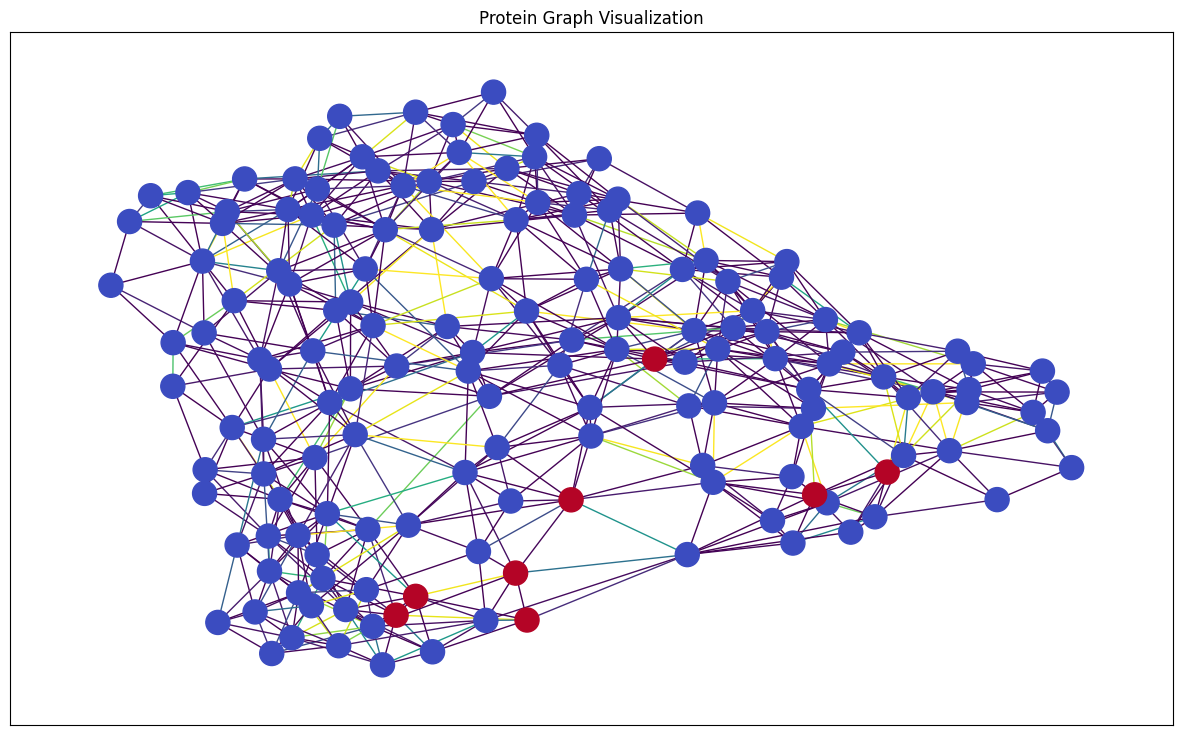

In [217]:
from torch_geometric.utils import to_networkx

G = to_networkx(x_1, to_undirected=True, edge_attrs=["edge_attr"])
visualize_graph(G, color=x_1.y)

In [ ]:

model, alphabet = torch.hub.load("facebookresearch/esm:main", "esm2_t33_650M_UR50D");
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results

Downloading: "https://github.com/facebookresearch/esm/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt


In [4]:
# Prepare data (first 2 sequences from ESMStructuralSplitDataset superfamily / 4)
data = [
    ("protein1", "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG"),
    ("protein2", "KALTARQQEVFDLIRDHISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE"),
    ("protein2 with mask","KALTARQQEVFDLIRD<mask>ISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE"),
    ("protein3",  "K A <mask> I S Q"),
]
batch_labels, batch_strs, batch_tokens = batch_converter(data)
batch_lens = (batch_tokens != alphabet.padding_idx).sum(1)

In [28]:
results = model(batch_tokens, repr_layers=[33], return_contacts=True)
token_representations = results["representations"][33]  

In [27]:
token_representations[0][0]

tensor([ 0.0744, -0.0747,  0.0824,  ..., -0.2394,  0.1661, -0.0306])

In [8]:
token_representations.shape

torch.Size([4, 73, 1280])

In [15]:
results["contacts"].shape

torch.Size([4, 71, 71])

In [90]:
# Generate per-sequence representations via averaging
# NOTE: token 0 is always a beginning-of-sequence token, so the first residue is token 1.
sequence_representations = []
for i, tokens_len in enumerate(batch_lens):
    sequence_representations.append(token_representations[i, 1 : tokens_len - 1].mean(0))

# Look at the unsupervised self-attention map contact predictions
import matplotlib.pyplot as plt
for (_, seq), tokens_len, attention_contacts in zip(data, batch_lens, results["contacts"]):
    print(attention_contacts.shape)
    print(attention_contacts[: tokens_len, : tokens_len].shape)
    plt.matshow(attention_contacts[: tokens_len, : tokens_len])
    plt.title(seq)
    plt.show()

NameError: name 'batch_lens' is not defined

# Map this fucking contacts to the ones created UwU